# ESIGMASur tutorial

This notebook illustrates the usage of `ESIGMASur`, which is a *non-spinning* *time-domain* surrogate model of the *(2,2)-mode* of `ESIGMAHM`.

> **Note:** If you are evaluating this notebook in its original location within the repository, the cell below will correctly set the path of the surrogate data files to the `bash` environment variable `ESIGMASUR_DATA_PATH`. However, if you have moved this notebook, please point `ESIGMASUR_DATA_PATH` to the path of the [surrogate data directory](https://github.com/gwnrtools/esigmapy/tree/master/esigmapy/surrogate/data) on your local machine. 

In [ ]:
import os

# Required for efficient surrogate evaluation by avoiding multi-threading overheads
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import matplotlib.pyplot as plt
import esigmapy.surrogate as esigmasur

# Configuring some plot settings
plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 12,
    }
)

# Point bash variable ESIGMASUR_DATA_PATH to the directory where surrogate data is stored (esigmapy/surrogate/data)
sur_data_dir = "../esigmapy/surrogate/data"
sur_data_dir = os.path.abspath(sur_data_dir)
os.environ["ESIGMASUR_DATA_PATH"] = sur_data_dir

No version information file '.version' found


## 1. InspiralESIGMASur

`InspiralESIGMASur` is a *non-spinning* *time-domain* surrogate model of `InspiralESIGMA`, the *inspiral* *(2,2)-mode* piece of `ESIGMAHM`. The surrogate is built using a new scalable eccentric surrogate modeling technique presented in [arxiv:2510.00116](https://arxiv.org/abs/2510.00116).

`InspiralESIGMASur` can generate eccentric inspiral waveforms of lengths up to $2.77 \times 10^{6}M$ for binaries with mass-ratios $q:=m_1/m_2 \in [1,6]$, and reference eccentricities and mean anomalies $e_{\rm{ref}} \in [0, 0.431]$ and $l_{\rm{ref}} \in [0, 2 \pi)$ measured at a reference time $t_{\rm{ref}} = -2.75 \times 10^6M$ before the end of the inspiral ($t=0$).

### 1.1 Waveform polarizations
The polarizations $h_+$ and $h_\times$ can be generated via the `get_inspiral_esigmasur_waveform` function. They are returned as `PyCBC` `TimeSeries` objects.

Surrogate data loaded successfully.


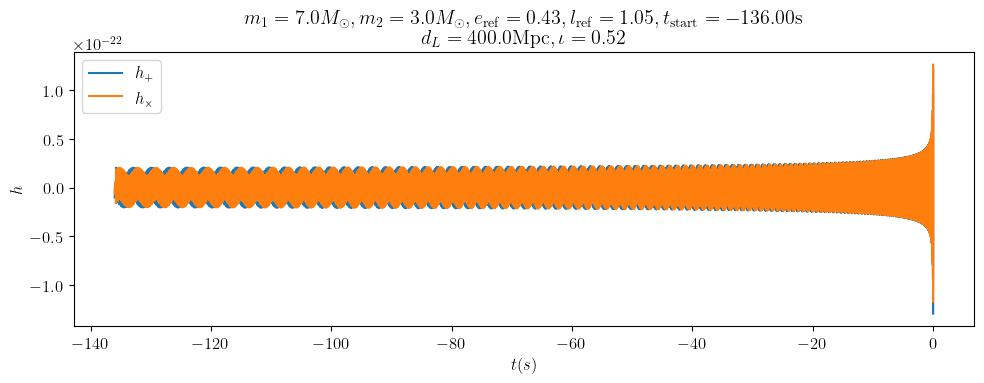

In [2]:
m1 = 7.0  # masses (in solar masses)
m2 = 3.0
reference_eccentricity = 0.43  # reference eccentricity
reference_mean_anomaly = 60 * np.pi / 180.0  # reference mean anomaly

distance = 400.0  # source luminosity distance (in Mpc)
inclination = 30 * np.pi / 180.0  # orbital inclination with line-of-sight

delta_t = 1 / 2**12  # time grid-spacing (in s)
# Waveform starting time (in s); 2.77e6M (the maximum surrogate length) corresponds
# to roughly 136s for a 10 Msun binary. t=0 corresponds to the end of waveform,
# so the starting time should be a negative real number
t_start = -136.0

hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t,
    t_start=t_start,
    distance=distance,
    inclination=inclination,
)

plt.figure(figsize=(10, 4))
plt.title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start:.2f}\rm{{s}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
hp.plot(label=r"$h_+$")
hc.plot(label=r"$h_\times$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

The first evaluation will be slower due to two one-time costs: (1) loading surrogate data from disk, and (2) `numba` JIT compilation of some routines.

### 1.2 Waveform modes
One can also generate the spin-weighted spherical harmonic modes via the `get_inspiral_esigmasur_modes` function. Only the $(2, \pm2)$ modes are supported currently.

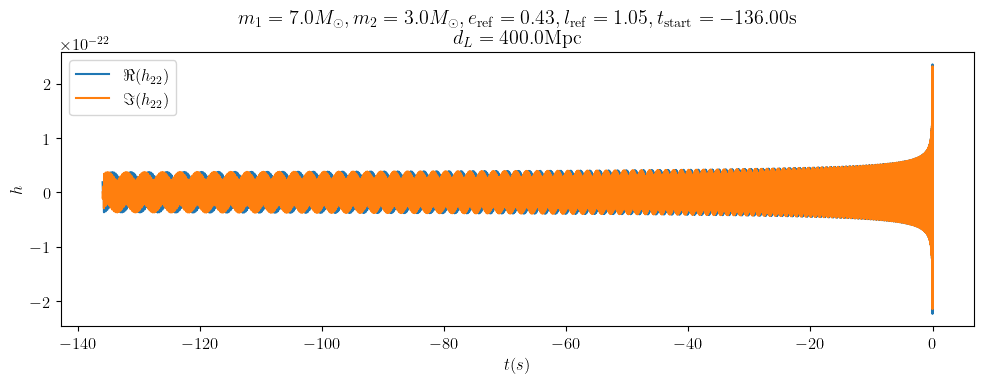

In [3]:
modes = esigmasur.get_inspiral_esigmasur_modes(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t,
    t_start=t_start,
    distance=distance,
)

plt.figure(figsize=(10, 4))
plt.title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start:.2f}\rm{{s}}$
          $d_L={distance}\rm{{Mpc}}$"""
)

mode_name = (2, 2)
ell, m = mode_name
plt.plot(
    modes[mode_name].sample_times.data,
    modes[mode_name].real().data,
    label=rf"$\Re(h_{{{ell} {m}}})$",
)
plt.plot(
    modes[mode_name].sample_times.data,
    modes[mode_name].imag().data,
    label=rf"$\Im(h_{{{ell} {m}}})$",
)
plt.legend(loc=2)
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.tight_layout()

### 1.3 Evolution of orbital elements
The surrogates of binary's orbital elements' evolution can also be accessed via the argument `return_orbital_params` in all of the above discussed waveform/mode functions. The available orbital elements are

- $e$: Orbital eccentricity
- $l$: Mean anomaly
- $x$: The post-Newtonian (PN) parameter. It's related to the orbit-averaged (azimuthal) orbital frequency

$e$ and $l$ surrogates are internally required for surrogate waveform generation to get the values of eccentricity and mean anomaly at empirical interpolation (EI) nodes (i.e., $e_{\rm{EI}}$ and $l_{\rm{EI}}$); see [arxiv:2510.00116](https://arxiv.org/abs/2510.00116) for details. $x$ surrogate is required by the merger-ringdown attachment algorithm (as detailed in [arxiv:2409.13866](https://arxiv.org/abs/2409.13866)) for producing an IMR waveform using the inspiral surrogate (demonstrated later in this notebook).

Text(0.5, 0, '$t (s)$')

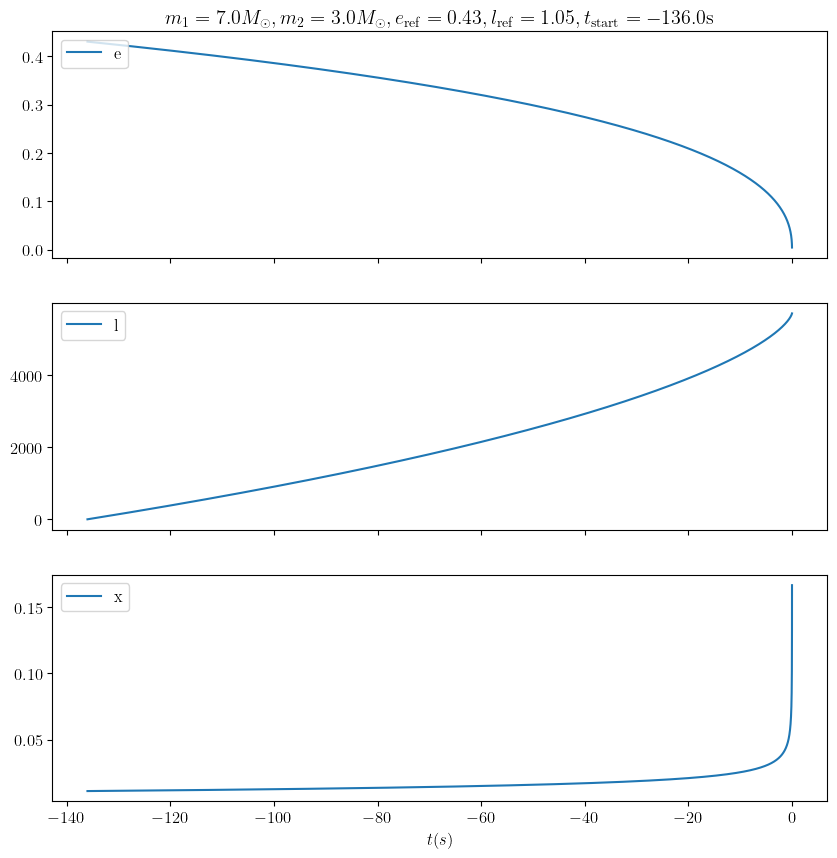

In [4]:
orb_params_list = ["e", "l", "x"]
orb_vars, hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t,
    t_start=t_start,
    distance=distance,
    inclination=inclination,
    return_orbital_params=orb_params_list,
)

fig, axs = plt.subplots(len(orb_params_list), sharex=True, figsize=(10, 10))
axs[0].set_title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start}\rm{{s}}$"""
)
for i, orb_params_name in enumerate(orb_params_list):
    axs[i].plot(
        orb_vars[orb_params_name].sample_times.data,
        orb_vars[orb_params_name].data,
        label=rf"{orb_params_name}",
    )
    axs[i].legend(loc=2)
plt.xlabel(r"$t (s)$")

---

## 2. IMRESIGMASur
The inspiral surrogate `InspiralESIGMASur` can be used as a drop-in replacement for `InspiralESIGMA`, the eccentric inspiral piece in the [`ESIGMA` framework](https://arxiv.org/abs/2409.13866), and can be smoothly attached to a quasi-circular plunge-merger-ringdown piece (`NRSur7dq4`, by default) to produce a complete inspiral-merger-ringdown (IMR) model. We call this hybrid IMR surrogate model `IMRESIGMASur`. 

**Note:** This is not a single eccentric IMR surrogate, but rather a hybrid of two surrogates: an eccentric inspiral surrogate (`InspiralESIGMASur`) and a quasi-circular plunge-merger-ringdown surrogate (`NRSur7dq4`).   

> **Note:** Running the following two cells will require installing the surrogate data files for `NRSur7dq4` (see the instructions at [`ESIGMAPy`'s wiki](https://github.com/gwnrtools/esigmapy)).

### 2.1 Waveform polarizations

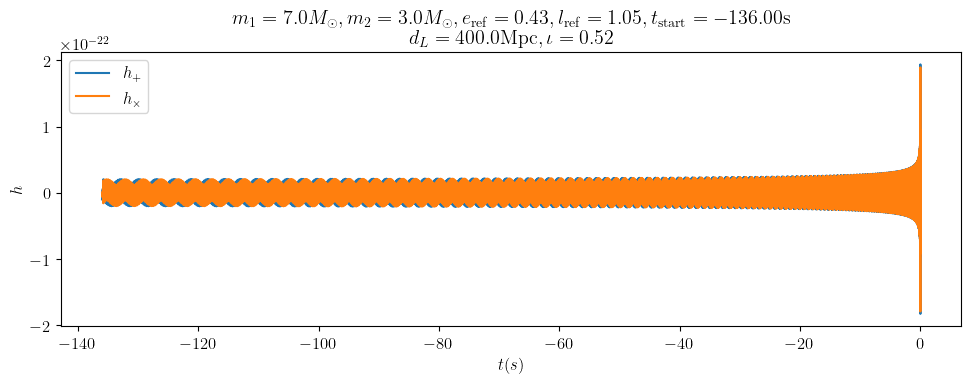

In [5]:
hp, hc = esigmasur.get_imr_esigmasur_waveform(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t,
    t_start=t_start,
    distance=distance,
    inclination=inclination,
)

plt.figure(figsize=(10, 4))
plt.title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start:.2f}\rm{{s}}$
          $d_L={distance}\rm{{Mpc}}, \iota={inclination:.2f}$"""
)
hp.plot(label=r"$h_+$")
hc.plot(label=r"$h_\times$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

### 2.2 Waveform Modes

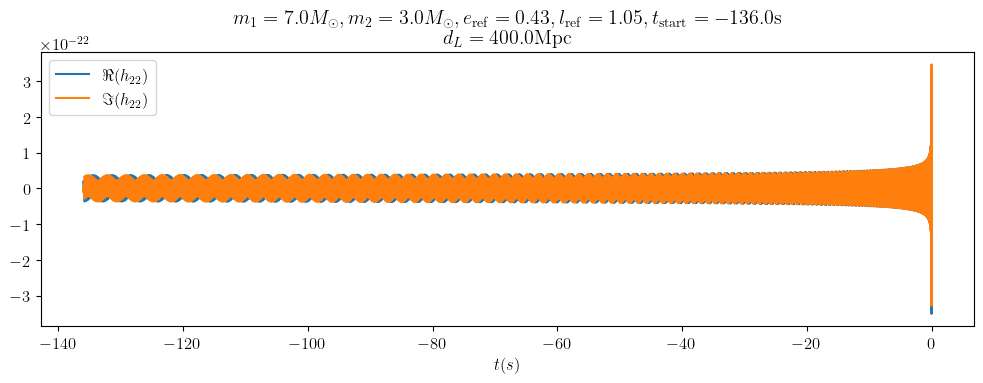

In [6]:
modes = esigmasur.get_imr_esigmasur_mode(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t,
    t_start=t_start,
    distance=distance,
)

mode_name = (2, 2)
ell, m = mode_name
plt.figure(figsize=(10, 4))
plt.title(
    rf"""$m_1={m1} M_\odot, m_2={m2} M_\odot, e_{{\rm{{ref}}}}={reference_eccentricity}, l_{{\rm{{ref}}}}={reference_mean_anomaly:.2f}, t_{{\rm{{start}}}}={t_start}\rm{{s}}$
          $d_L={distance}\rm{{Mpc}}$"""
)
plt.plot(
    modes[mode_name].sample_times.data,
    modes[mode_name].real().data,
    label=rf"$\Re(h_{{{ell} {m}}})$",
)
plt.plot(
    modes[mode_name].sample_times.data,
    modes[mode_name].imag().data,
    label=rf"$\Im(h_{{{ell} {m}}})$",
)
plt.legend(loc=2)
plt.xlabel(r"$t (s)$")
plt.tight_layout()

<hr style="border: 2px solid #555; margin: 20px 0;">

## 3. Advanced features and demonstrations

### 3.1 Evaluation over generic time-grids
The inspiral surrogate `InspiralESIGMASur` can also be evaluated at a user-specified time-grid (sorted in ascending order), which can be *non-uniform*. This time-grid can be supplied to the `times` argument in the surrogate's waveform/mode generation functions as a `NumPy` array. 

As an example, we use this feature to sample the waveform uniformly in *GW phase* instead of time. Consequently, in the plot below one can observe that
1. within any cycle, the time sampling is denser near the peaks and troughs, where the waveform changes rapidly
2. the time-sampling becomes denser near the end of inspiral, where the waveform evolves rapidly

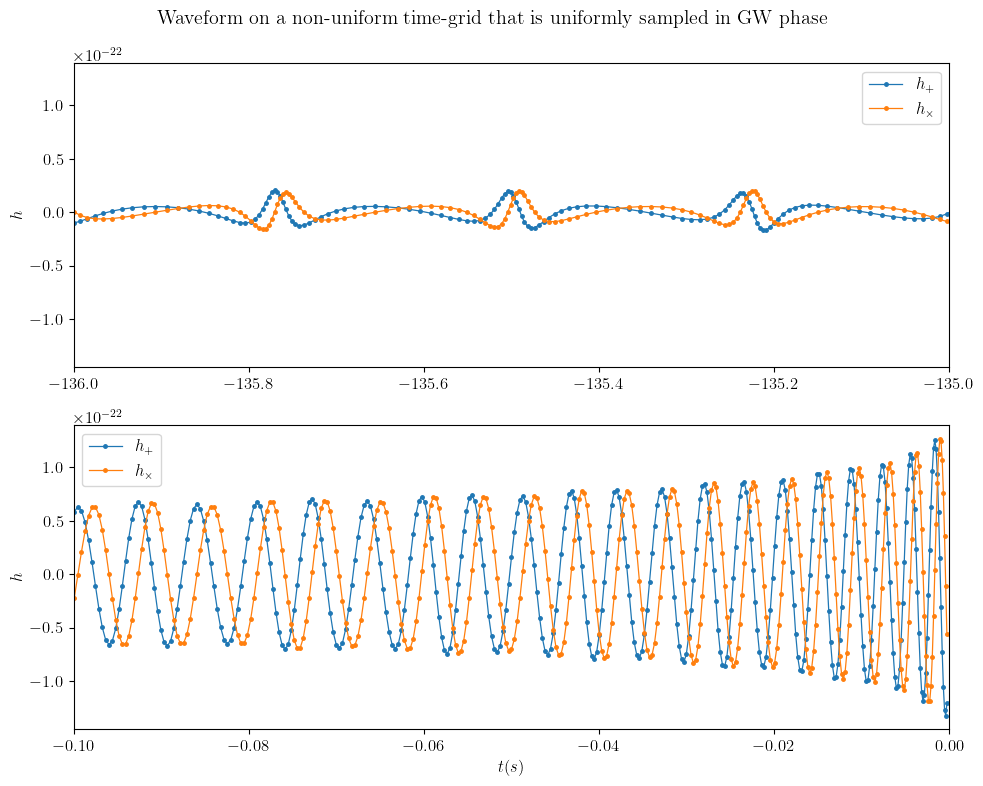

In [7]:
# Generating the same waveform as above
hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    delta_t=delta_t,
    t_start=t_start,
    distance=distance,
    inclination=inclination,
)

# Computing a non-uniform time-grid that is uniformly sampled in GW phase instead
phase_gw = np.unwrap(np.arctan2(hc.data, hp.data))
num_points_per_cycle = 18
uniform_phase_grid = np.linspace(
    phase_gw[2],
    phase_gw[-2],
    int(num_points_per_cycle * (phase_gw[-2] - phase_gw[2]) / (2 * np.pi)),
    endpoint=True,
)
time_grid_uniformly_sampled_in_phase = np.interp(
    uniform_phase_grid, phase_gw, hp.sample_times.data
)

# Generating the waveform on the non-uniform time grid by passing it to the `times` argument
t, hp, hc = esigmasur.get_inspiral_esigmasur_waveform(
    mass1=m1,
    mass2=m2,
    reference_eccentricity=reference_eccentricity,
    reference_mean_anomaly=reference_mean_anomaly,
    times=time_grid_uniformly_sampled_in_phase,
    distance=distance,
    inclination=inclination,
    return_pycbc_timeseries=False,  # When giving a custom time-grid, can't return waveform as a PyCBC TimeSeries object
)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.suptitle(
    r"Waveform on a non-uniform time-grid that is uniformly sampled in GW phase"
)

ax1.plot(t, hp, marker=".", lw=0.9, markersize=5, label=r"$h_+$")
ax1.plot(t, hc, marker=".", lw=0.9, markersize=5, label=r"$h_\times$")
ax1.set_ylabel("$h$")
ax1.set_xlim(-136.0, -135.0)
ax1.legend()

ax2.plot(t, hp, marker=".", lw=0.9, markersize=5, label=r"$h_+$")
ax2.plot(t, hc, marker=".", lw=0.9, markersize=5, label=r"$h_\times$")
ax2.set_ylabel("$h$")
ax2.set_xlim(-0.1, 0.0)
ax2.legend()

plt.xlabel(r"$t (s)$")
plt.tight_layout()

### 3.2 Surrogate metrics
One can explore the internals of `InspiralESIGMASur` by accessing the base surrogate object via the `get_surrogate_object` function.

As an example, we access the parameter space points at which the surrogate was trained from the surrogate's metadata file and print their total number. We also access the number of basis functions required by the various individual surrogate data-pieces (see [arxiv:2510.00116](https://arxiv.org/abs/2510.00116) for their meanings) by accessing their respective "B-matrices" produced by the Empirical Interpolation Method (EIM) (see Eq. 19 of [arXiv:1308.3565](https://arxiv.org/abs/1308.3565)).

In [8]:
# Expose the base surrogate object
sur = esigmasur.get_surrogate_object()
# Surrogate's training parameter space: [q, e_ref, l_ref]
param_space = sur.get_metadata("training_param_space")

print(f"The surrogate is trained over {len(param_space)} InspiralESIGMA waveforms.\n")

full_eccentric_data_piece_names = {
    "res_amp": "Residual amplitude",
    "res_phase": "Residual phase",
    "res_circ_phase": "Residual circular phase",
    "e": "Eccentricity dynamics",
    "shifted_mean_anomaly": "Shifted mean anomaly dynamics",
}

full_circular_data_piece_names = {
    "amp": "Circular amplitude",
    "phase": "Circular phase",
}

print(f"The surrogate uses the following number of basis functions:")
for key, value in full_eccentric_data_piece_names.items():
    # Accessing the EIM-B matrices to find the number of basis functions
    print(f"{value}: {len(sur.eim_B[key])}")

for key, value in full_circular_data_piece_names.items():
    print(f"{value}: {len(sur.circ_sur.eim_B[key])}")

The surrogate is trained over 1404 InspiralESIGMA waveforms.

The surrogate uses the following number of basis functions:
Residual amplitude: 36
Residual phase: 21
Residual circular phase: 4
Eccentricity dynamics: 7
Shifted mean anomaly dynamics: 7
Circular amplitude: 4
Circular phase: 4


### 3.3 Surrogate's domain of validity in starting GW frequency
`InspiralESIGMASur` can generate waveforms of lengths up to $2.77 \times 10^6M$ in time. However, in order to better understand the validity of the surrogate in terms of starting GW frequencies, we plot the minimum frequency with which these waveforms can be started for a $10M_\odot$ binary across the surrogate's training parameter space. Equivalently, one can also think in terms of the minimum binary mass for which the waveforms can be started from a fixed frequency, say $15\rm{Hz}$.

We find these metrics below by utilizing the starting values of the PN parameter $x$ stored in the surrogate's metadata at the training parameter space points.

**Note:** Since the frequencies are extracted from the PN parameter $x$, these correspond to the orbit-averaged (azimuthal) GW frequency, and NOT the instantaneous (2,2)-mode frequency.

The minimum GW frequency till which the surrogate can generate waveforms for a 10.0M_Sun binary across its entire parameter space = 12.5Hz
Equivalently, the minimum total binary mass for which the surrogate can generate waveforms from 15.0Hz across its entire parameter space = 8.3M_Sun


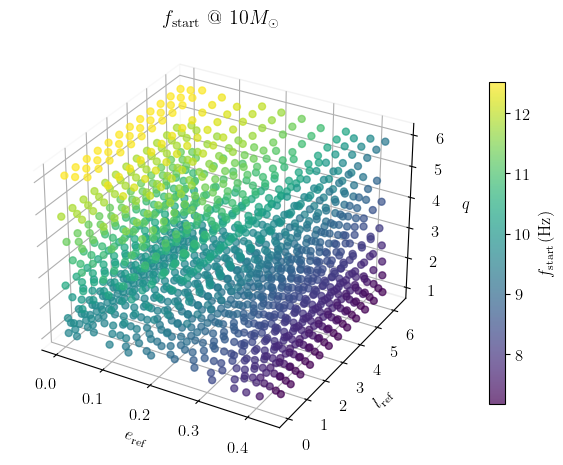

In [9]:
from esigmapy.utils import f22_from_x

# Total binary mass (in M_Sun) for which to compute the frequencies
M_eval = 10
# Values of the PN parameter "x" at the starting of the surrogate's full length
x_min_array = sur.get_metadata("x_min_array")
f_min_at_M_eval = f22_from_x(np.max(x_min_array), M=M_eval)
print(
    f"The minimum GW frequency till which the surrogate can generate waveforms for a {M_eval:.1f}M_Sun binary across its entire parameter space = {f_min_at_M_eval:.1f}Hz"
)

f_compute = 15.0
M_min_at_fcompute = M_eval * (f_min_at_M_eval / f_compute)
print(
    f"Equivalently, the minimum total binary mass for which the surrogate can generate waveforms from {f_compute}Hz across its entire parameter space = {M_min_at_fcompute:.1f}M_Sun"
)

# Converting PN parameter to the orbit-averaged GW frequency
plot_data = f22_from_x(x_min_array, M=M_eval)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

img = ax.scatter(
    param_space[:, 1],
    param_space[:, 2],
    param_space[:, 0],
    c=plot_data,
    cmap="viridis",
    s=25,
    alpha=0.7,
)

cbar = fig.colorbar(img, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label(r"$f_{\rm{start}} \, (\rm{Hz})$")

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.set_title(rf"$f_{{\rm{{start}}}}$ @ ${M_eval:.0f} M_\odot$")
ax.set_zlabel(r"$q$")
ax.set_xlabel(r"$e_{\rm{ref}}$")
ax.set_ylabel(r"$l_{\rm{ref}}$")

plt.tight_layout()
plt.show()

### 3.4 Surrogate's evaluation speed  

We compute the evaluation speed of `InspiralESIGMASur` at random points in mass-ratio $q = m_1/m_2$, reference eccentricity $e_{\rm{ref}}$ and reference mean anomaly $l_{\rm{ref}}$. The surrogate is started such that its starting frequency is $15\rm{Hz}$, and the waveforms are sampled at $4096 \rm{Hz}$.

> **Note:** The following cell may take about a minute to run.

In [10]:
import time
from esigmapy.utils import x_from_f22

num_evals_per_mass = 25
# Starting frequency (in Hz) from which to generate the surrogate waveforms for timing.
f_start = 15.0
delta_t = 1 / 2**12
total_mass_array = np.asarray([20, 30, 40, 50, 60, 80, 100])

NLOOP = 10


def speeds(M, q, e_ref, l_ref, f_start, delta_t):
    m1 = q * M / (1 + q)
    m2 = M / (1 + q)
    t, orb_vars, modes = esigmasur.get_inspiral_esigmasur_modes(
        mass1=m1,
        mass2=m2,
        reference_eccentricity=e_ref,
        reference_mean_anomaly=l_ref,
        delta_t=delta_t,
        t_start=None,  # Generate the surrogate with its full duration
        return_pycbc_timeseries=False,
        return_orbital_params=["x"],
    )
    # Finding the time at which the surrogate reaches
    # the GW frequency of f_start
    x_start = x_from_f22(f_start, M=M)
    idx = np.argmax(orb_vars["x"] >= x_start)
    t_start = t[idx]

    t1 = time.perf_counter()
    t, modes = esigmasur.get_inspiral_esigmasur_modes(
        mass1=m1,
        mass2=m2,
        reference_eccentricity=e_ref,
        reference_mean_anomaly=l_ref,
        delta_t=delta_t,
        # Generate the surrogate with a duration such that
        # it starts from a GW frequency of f_start
        t_start=t_start,
        return_pycbc_timeseries=False,
    )
    sur_time = time.perf_counter() - t1

    if sur_time < 2.5e-2:
        temp_time = 0
        for _ in range(NLOOP - 1):
            t1 = time.perf_counter()
            t, modes = esigmasur.get_inspiral_esigmasur_modes(
                mass1=m1,
                mass2=m2,
                reference_eccentricity=e_ref,
                reference_mean_anomaly=l_ref,
                delta_t=delta_t,
                # Generate the surrogate with a duration such that
                # it starts from a GW frequency of f_start
                t_start=t_start,
                distance=distance,
                return_pycbc_timeseries=False,
            )
            temp_time += time.perf_counter() - t1
        sur_time += temp_time
        sur_time /= NLOOP
    return sur_time


total_mass_array = total_mass_array[total_mass_array > M_min_at_fcompute]
total_mass_array = np.r_[M_min_at_fcompute, total_mass_array]
sur_eval_times_dict = {}

for total_mass in total_mass_array:
    rng = np.random.default_rng(seed=37)
    q_array = rng.uniform(1, 6, size=num_evals_per_mass)
    e_array = rng.uniform(0, 0.43, size=num_evals_per_mass)
    l_array = rng.uniform(0, 2 * np.pi, size=num_evals_per_mass)

    sur_eval_times = []
    for i in range(num_evals_per_mass):
        sur_eval_times.append(
            speeds(
                M=total_mass,
                q=q_array[i],
                e_ref=e_array[i],
                l_ref=l_array[i],
                f_start=f_start,
                delta_t=delta_t,
            )
        )
    sur_eval_times_dict[total_mass] = sur_eval_times
    print(f"Timing completed for M = {total_mass:.2f} M_Sun")

Timing completed for M = 8.35 M_Sun
Timing completed for M = 20.00 M_Sun
Timing completed for M = 30.00 M_Sun
Timing completed for M = 40.00 M_Sun
Timing completed for M = 50.00 M_Sun
Timing completed for M = 60.00 M_Sun
Timing completed for M = 80.00 M_Sun
Timing completed for M = 100.00 M_Sun


The computation was performed on AMD EPYC 7352 24-Core Processor operating at 2295.905MHz.


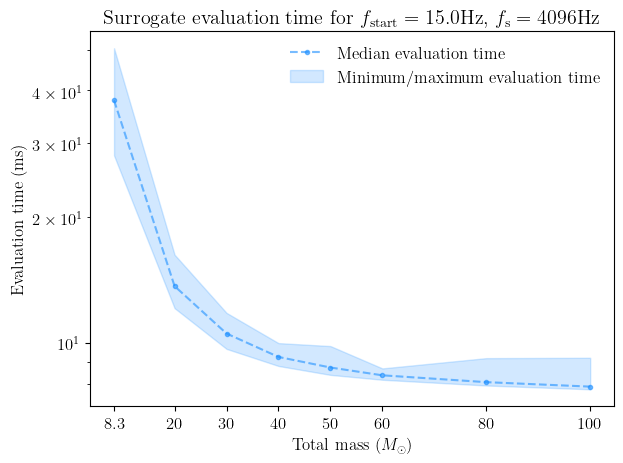

In [11]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots()
ax.set_title(
    rf"Surrogate evaluation time for $f_{{\rm{{start}}}} = {f_start} \rm{{Hz}}$, $f_{{\rm{{s}}}} = {1/delta_t:.0f} \rm{{Hz}}$"
)
ax.set_xlabel("Total mass ($M_\\odot$)")
ax.set_ylabel("Evaluation time (ms)")
ax.set_yscale("log")

alpha_scatter = 0.6
alpha_fill = 0.2
color = "dodgerblue"

for mass, eval_times in sur_eval_times_dict.items():
    eval_times = np.asarray(eval_times)

sur_eval_times_array = np.asarray(list(sur_eval_times_dict.values()))
sur_eval_times_median = np.median(sur_eval_times_array, axis=-1)
sur_speed_min = np.min(sur_eval_times_array, axis=-1)
sur_speed_max = np.max(sur_eval_times_array, axis=-1)

ax.plot(
    total_mass_array,
    sur_eval_times_median * 1.0e3,
    ls="--",
    color=color,
    marker=".",
    alpha=alpha_scatter,
    label="Median evaluation time",
)
ax.fill_between(
    total_mass_array,
    sur_speed_min * 1.0e3,
    sur_speed_max * 1.0e3,
    color=color,
    alpha=alpha_fill,
    label="Minimum/maximum evaluation time",
)


# To display only the first tick with a decimal entry
def mixed_formatter(x, pos):
    # pos = index of tick in visible ticks
    if pos == 0:
        return f"{x:.1f}"  # first tick: 1 decimal place
    else:
        return f"{x:.0f}"  # others: no decimals


ax.xaxis.set_major_formatter(mticker.FuncFormatter(mixed_formatter))
plt.xticks(total_mass_array)
plt.legend(frameon=False)
plt.tight_layout()

import subprocess

cpu_name = (
    subprocess.check_output("lscpu | grep 'Model name'", shell=True)
    .decode()
    .split(":")[1]
    .strip()
)
cpu_freq = (
    subprocess.check_output("grep 'cpu MHz' /proc/cpuinfo | head -1", shell=True)
    .decode()
    .split(":")[1]
    .strip()
)
print(f"The computation was performed on {cpu_name} operating at {cpu_freq}MHz.")